In [2]:
"""
Loading latent space data and splitting train-test

"""

import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader

# Load latents
ttbar = np.loadtxt("/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_1/ttbar_3200-3600_latents.txt")   # shape (400, d)
ggf   = np.loadtxt("/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml/models_1/ggf_3200-3600_latents.txt")     # shape (400, d)

# Labels: ttbar=0, ggf=1
y_ttbar = np.zeros(len(ttbar))
y_ggf   = np.ones(len(ggf))

# Split: first 300 train, last 100 test
X_train = np.vstack([ttbar[:300], ggf[:300]])
y_train = np.hstack([y_ttbar[:300], y_ggf[:300]])

X_test  = np.vstack([ttbar[300:], ggf[300:]])
y_test  = np.hstack([y_ttbar[300:], y_ggf[300:]])

# Convert to torch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test  = torch.tensor(X_test, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

In [3]:
"""
Defining simple 2-layer neural network
"""

import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()

        self.net0 = self.net = nn.Sequential(
            nn.Linear(input_dim, 2),
        
        )
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)  # 2 classes
        )

        self.net2 = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
         )

    def forward(self, x):
        return self.net0(x)

model = MLP(input_dim=X_train.shape[1])

In [4]:
"""
Training set-up
"""

import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

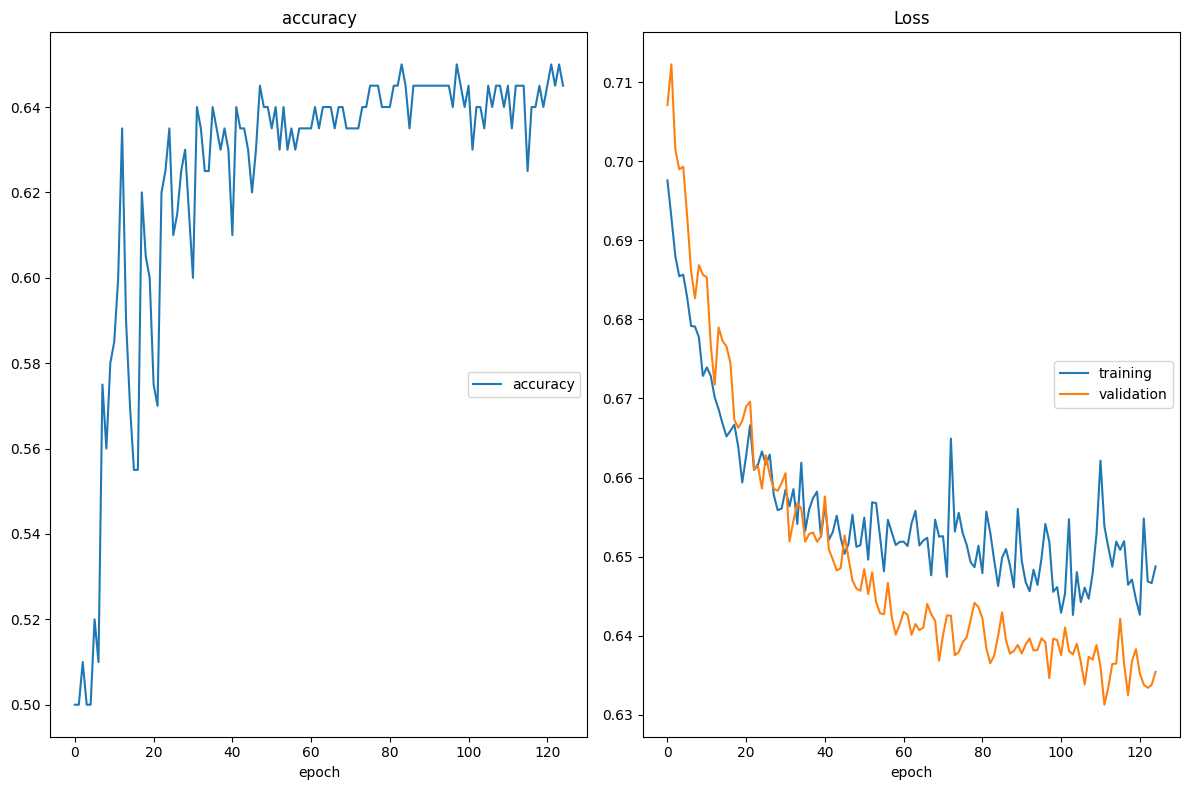

accuracy
	accuracy         	 (min:    0.500, max:    0.650, cur:    0.645)
Loss
	training         	 (min:    0.643, max:    0.698, cur:    0.649)
	validation       	 (min:    0.631, max:    0.712, cur:    0.635)


In [5]:
from livelossplot import PlotLosses

liveloss = PlotLosses()

for epoch in range(125):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Evaluate on test
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)

            test_loss += loss.item()
            preds = out.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    test_loss /= len(test_loader)
    accuracy = correct / total

    liveloss.update({
        'loss': train_loss,
        'val_loss': test_loss,
        'accuracy': accuracy
    })
    liveloss.send()

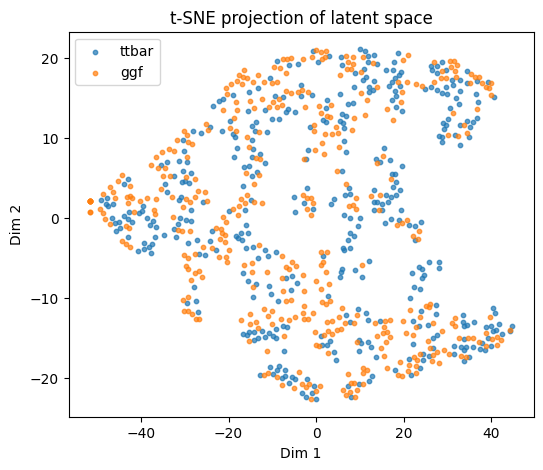

In [7]:
"""
tSNE Projection

"""

import numpy as np

# Stack data
X = np.vstack([ttbar, ggf])
y = np.concatenate([y_ttbar, y_ggf])

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,        # try 5–50 depending on structure
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[y==0, 0], X_tsne[y==0, 1], s=10, label='ttbar', alpha=0.7)
plt.scatter(X_tsne[y==1, 0], X_tsne[y==1, 1], s=10, label='ggf', alpha=0.7)
plt.legend()
plt.title("t-SNE projection of latent space")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


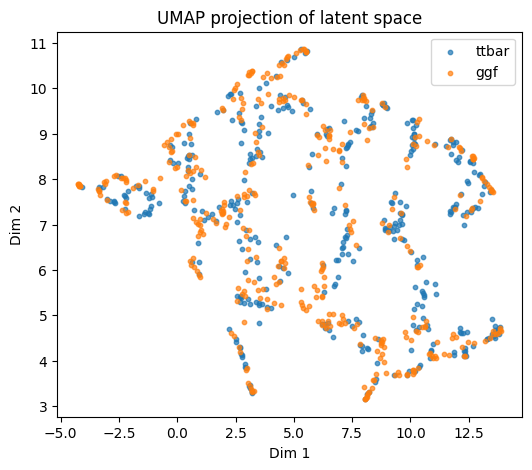

In [8]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,    # local vs global structure
    min_dist=0.1,      # clustering tightness
    metric='euclidean',
    random_state=42
)

X_umap = umap_model.fit_transform(X)

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_umap[y==0, 0], X_umap[y==0, 1], s=10, label='ttbar', alpha=0.7)
plt.scatter(X_umap[y==1, 0], X_umap[y==1, 1], s=10, label='ggf', alpha=0.7)
plt.legend()
plt.title("UMAP projection of latent space")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [14]:
"""
KNN Classifier
"""

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("KNN accuracy:", accuracy_score(y_test, y_pred))

KNN accuracy: 0.6125


In [16]:
"""
Local Label Purity

"""

from sklearn.neighbors import NearestNeighbors

k = 20
nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
distances, indices = nbrs.kneighbors(X)

purities = []

for i in range(len(X)):
    neighbor_labels = y[indices[i][1:]]  # exclude self
    purity = (neighbor_labels == y[i]).mean()
    purities.append(purity)

print("Average local purity:", np.mean(purities))

Average local purity: 0.5424375
